[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github//incubodac/GradCamTP/blob/main/GradCam_fig2_blip.ipynb)

In [21]:
import torch
from PIL import Image
from resources.models import load_model_and_preprocess
import torch, gc
gc.collect()
torch.cuda.empty_cache()



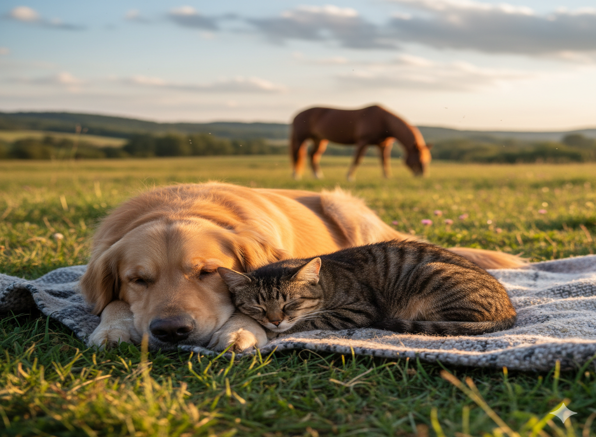

In [22]:
raw_image = Image.open("./imgs/perro_gato_caballo.png").convert("RGB")
display(raw_image.resize((596, 437)))

In [23]:
# setup device to use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
caption = "dog and cat on grass a horse in background."

In [24]:
model, vis_processors, text_processors = load_model_and_preprocess("blip_image_text_matching", "base", device=device, is_eval=True)


/home/dac/miniconda3/envs/gradcam/lib/python3.11/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [25]:
from matplotlib import pyplot as plt
from lavis.common.gradcam import getAttMap
from lavis.models.blip_models.blip_image_text_matching import compute_gradcam
import numpy as np

dst_w = 720
w, h = raw_image.size
scaling_factor = dst_w / w

resized_img = raw_image.resize((int(w * scaling_factor), int(h * scaling_factor)))
norm_img = np.float32(resized_img) / 255

In [26]:
img = vis_processors["eval"](raw_image).unsqueeze(0).to(device)
txt = text_processors["eval"](caption)

In [27]:
txt_tokens = model.tokenizer(txt, return_tensors="pt").to(device)
gradcam, _ = compute_gradcam(model, img, txt, txt_tokens, block_num=7)

In [28]:
avg_gradcam = getAttMap(norm_img, gradcam[0][1].detach().cpu().numpy(), blur=True)


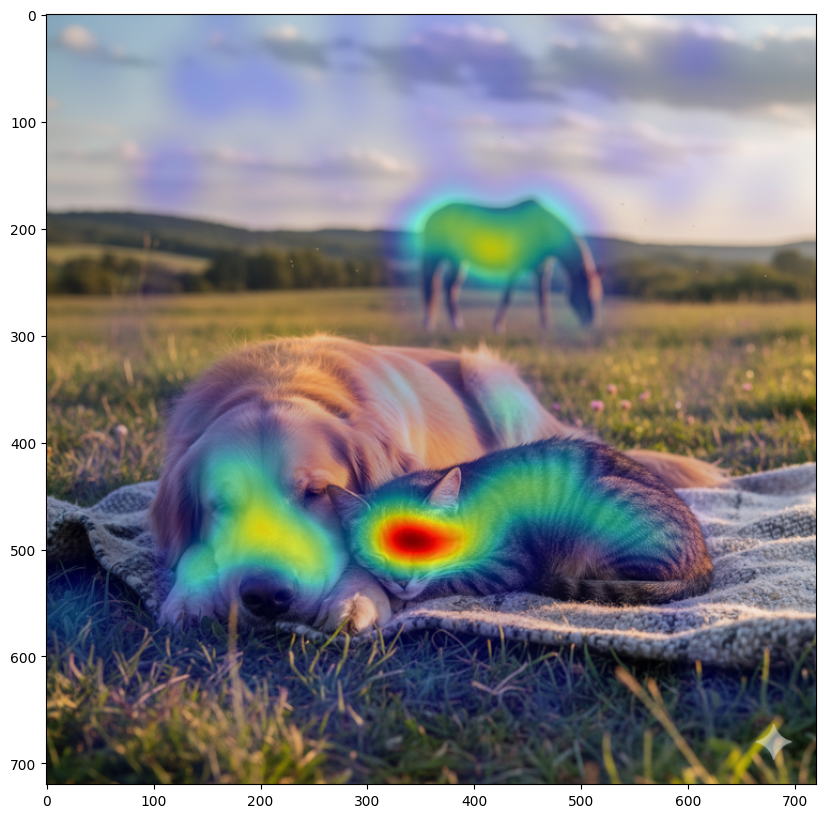

In [29]:
# fig, ax = plt.subplots(num_image, 1, figsize=(15,5*num_image))
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(avg_gradcam)


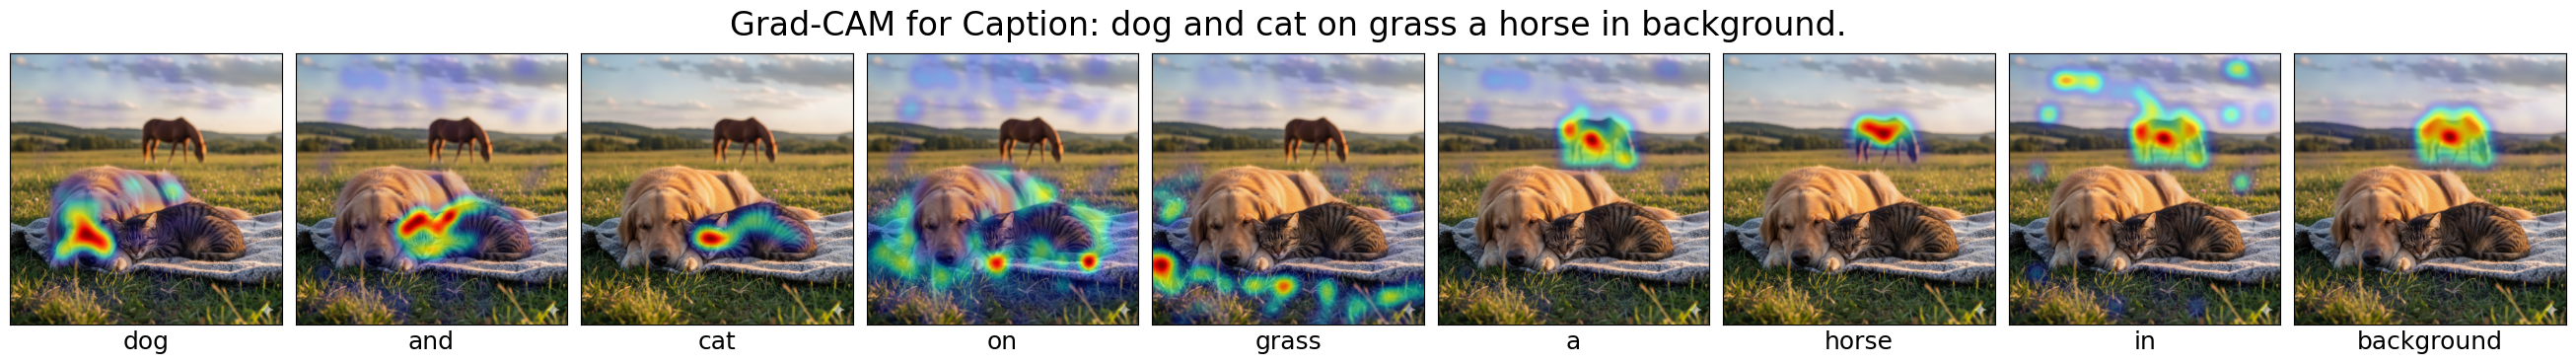

In [30]:
# num_image = len(txt_tokens.input_ids[0]) - 2

# gradcam_iter = iter(gradcam[0][2:-1])
# token_id_iter = iter(txt_tokens.input_ids[0][1:-1])
# # arrange plots horizontally
# fig, ax = plt.subplots(1, num_image, figsize=(5 * num_image, 5))
# fig.suptitle("Grad-CAM for Caption: " + caption, fontsize=16)
# fig.tight_layout(pad=3.0)
# #tight horizontal layout remover spaces between subplots
# fig.subplots_adjust(wspace=0.001)

# for i, (gradcam, token_id) in enumerate(zip(gradcam_iter, token_id_iter)):
#     word = model.tokenizer.decode([token_id])
#     # Convert the gradcam tensor to a numpy array before passing to getAttMap
#     gradcam_np = gradcam.detach().cpu().numpy()
#     gradcam_image = getAttMap(norm_img, gradcam_np, blur=True)
#     ax[i].imshow(gradcam_image)
#     ax[i].set_yticks([])
#     ax[i].set_xticks([])
#     ax[i].set_xlabel(word)
#     ax[i].xaxis.label.set_size(24)
num_image = len(txt_tokens.input_ids[0]) - 2

gradcam_iter = iter(gradcam[0][2:-1])
token_id_iter = iter(txt_tokens.input_ids[0][1:-1])

# Create more compact figure with smaller width per subplot
fig, ax = plt.subplots(1, num_image, figsize=(3 * num_image, 4))
fig.suptitle("Grad-CAM for Caption: " + caption, fontsize=24)

# Remove tight_layout and use subplots_adjust for more control
fig.subplots_adjust(
    wspace=0.05,    # Very small horizontal spacing
    hspace=0.3,     # Space for labels
    left=0.02,      # Reduce left margin
    right=0.98,     # Reduce right margin
    top=0.9,        # Space for title
    bottom=0.15     # Space for labels
)

for i, (gradcam, token_id) in enumerate(zip(gradcam_iter, token_id_iter)):
    word = model.tokenizer.decode([token_id])
    # Convert the gradcam tensor to a numpy array before passing to getAttMap
    gradcam_np = gradcam.detach().cpu().numpy()
    gradcam_image = getAttMap(norm_img, gradcam_np, blur=True)
    ax[i].imshow(gradcam_image)
    ax[i].set_yticks([])
    ax[i].set_xticks([])
    ax[i].set_xlabel(word, fontsize=18)  # Slightly smaller font
fig.savefig("figures/blip_gradcam_compact.png", dpi=300)